## 读取数据集

- https://www.osgeo.cn/rasterio/quickstart.html
- https://www.osgeo.cn/pygis/rasterio-begin.html
- https://blog.csdn.net/m0_56729804/article/details/133995195

Rasterio是一个Python库，专门用于栅格数据的读写操作。
 
支持多种栅格数据格式，如GeoTIFF、ENVI和HDF5，为处理和分析栅格数据提供了强大的工具。
 
Rasterio适用于各种栅格数据应用，如卫星遥感、地图制作等。通过Rasterio，用户可以方便地读取、写入和操作栅格数据，提高数据处理效率。
 
Rasterio还支持自定义栅格数据类型和变换操作，具有很高的灵活性和可扩展性。

In [15]:
import os
from typing import Union


def file_type_filter(file_list: list, file_type: Union[str, list]) -> list:
    """
    筛选文件列表中的指定文件类型
    :param file_list: 文件列表
    :param file_type: 文件类型(可以是字符串或列表)
    :return: 筛选后的文件列表
    """
    if isinstance(file_type, str):
        return [i for i in file_list if i.endswith(file_type)]
    else:
        return [i for i in file_list if any(i.endswith(ft) for ft in file_type)]


raster_list = file_type_filter(os.listdir("./raster"), ["tif"])
raster_list

['ASTGTM2_N24E118_dem.tif', 'ASTGTM2_N24E119_dem.tif']

### DEM

In [16]:
# 读取栅格数据
import rasterio as rs

ds = rs.open("./raster/ASTGTM2_N24E118_dem.tif")
ds

<open DatasetReader name='./raster/ASTGTM2_N24E118_dem.tif' mode='r'>

In [17]:
print(f"波段数据：{ds.count}") 
print(f"波段索引：{ds.indexes}")
print(f"数据类型：{ds.dtypes}")
print(f"投影信息：{ds.crs}")
print(f"数据集形状：{ds.shape}")
print(f"数据集HW：{ds.height},{ds.width}")

波段数据：1
波段索引：(1,)
数据类型：('int16',)
投影信息：EPSG:4326
数据集形状：(3601, 3601)
数据集HW：3601,3601


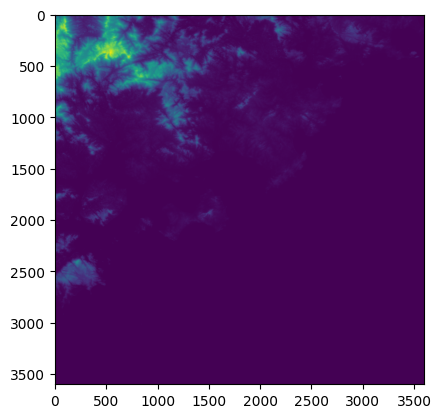

In [18]:
from matplotlib import pyplot
pyplot.imshow(ds.read(1))
pyplot.show()

In [19]:
ds.bounds

BoundingBox(left=117.99986111111112, bottom=23.99986111111111, right=119.0001388888889, top=25.000138888888888)

In [20]:
band1 = ds.read(1) # 读取band1
band1   # read() 返回numpy n-d数组

array([[232, 242, 248, ...,   0,   0,   0],
       [236, 243, 248, ...,   0,   0,   0],
       [233, 240, 250, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]],
      shape=(3601, 3601), dtype=int16)

### 仿射变换 transform

将(行y、列x)坐标中像素位置映射到空间位置(lng, lat)的仿射变换矩阵

Affine(a, b, c, d, e, f)
- a：x方向的分辨率(经度方向每个像素代表的单位)
- b：x方向的旋转/倾斜(通常为0)
- c：左上角像素中心点的x坐标(经度)
- d：y方向的旋转/倾斜(通常为0)
- e：y方向的分辨率(纬度方向每个像素代表的单位，通常为负值表示北向减小)
- f：左上角像素中心点的y坐标(纬度)

变换矩阵将像素坐标(列x,行y)转换为地理坐标(lng,lat)的公式
- lng = a * x + b * y + c
- lat = d * x + e * y + f

矩阵的乘积 (0, 0) 数据集左上角的行和列坐标是左上角的原坐标0点空间位置

In [21]:
ds.transform

Affine(0.0002777777777777778, 0.0, 117.99986111111112,
       0.0, -0.0002777777777777778, 25.000138888888888)

In [22]:
# 栅格原点
ds.transform * (0,0)

(117.99986111111112, 25.000138888888888)

In [23]:
# 右下角的位置
ds.transform * (ds.width, ds.height)

(119.0001388888889, 23.99986111111111)